In [1]:
from stochastic_rates import (
    fetch_fred_series, calibrate_vasicek, calibrate_cir,
    simulate_vasicek_paths, simulate_cir_paths, plot_fan_chart_with_labels, 
    analyze_paths, print_model_assumptions, plot_fan_chart_with_mean
)

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple


def plot_fan_chart(paths, title="Monte Carlo Paths", quantiles=(5,25,50,75,95)):
    """Fixed version of plot_fan_chart for Vasicek/CIR paths."""
    T, N = paths.shape
    horizon = np.arange(T)
    qs = np.percentile(paths, q=list(quantiles), axis=1)  # shape (len(q), T)

    plt.figure(figsize=(9, 5))
    # show a few sample paths
    for i in range(min(20, N)):
        plt.plot(horizon, paths[:, i], linewidth=0.6, alpha=0.4)
    # overlay percentile bands
    for i in range(qs.shape[0]):
        plt.plot(horizon, qs[i, :], linewidth=2)
    plt.title(title)
    plt.xlabel("Step")
    plt.ylabel("Rate")
    plt.tight_layout()
    plt.show()


c:\Users\lysla\OneDrive\Desktop\MBS Project File\Monte Carlo Rate\stochastic_rates.py:83: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s = s.resample(freq).mean().dropna()


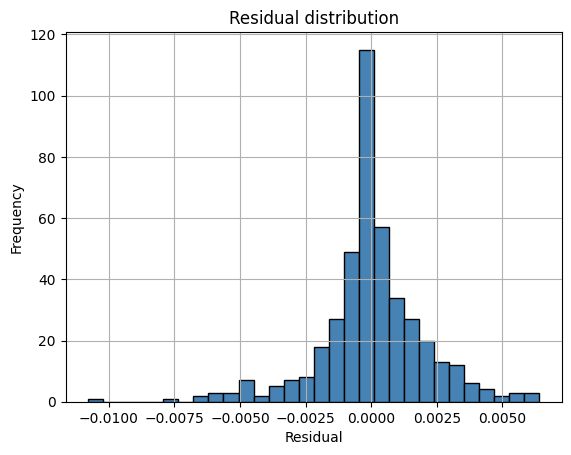

R² of Vasicek OLS fit: 0.9919


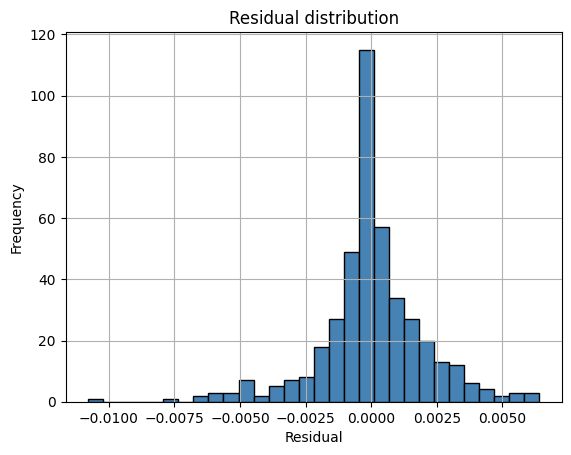

R² of CIR OLS fit: 0.9919

📘 Vasicek Model Assumptions

1. The short rate follows an Ornstein–Uhlenbeck process:
       dr_t = κ(θ – r_t) dt + σ dW_t

2. The process is Gaussian → r_t can become negative.
3. Mean reversion speed κ > 0 pulls rates toward long-run mean θ.
4. Volatility σ is constant over time.
5. The market price of risk is constant (under risk-neutral measure if pricing).
6. Stationary distribution:  N(θ, σ²/(2κ)).
7. Suitable for analytical bond pricing but not for ensuring strictly positive rates.


📗 CIR Model Assumptions

1. The short rate follows a square-root diffusion:
       dr_t = κ(θ – r_t) dt + σ√(r_t) dW_t

2. Volatility depends on √r_t → smaller near zero, preventing negatives.
3. Rates remain non-negative if the Feller condition 2κθ ≥ σ² holds.
4. Mean reversion κ > 0 toward long-run mean θ.
5. Stationary distribution: Gamma(shape = 2κθ/σ², scale = σ²/(2κ)).
6. More realistic for modeling short rates and credit spreads.

Interpretation Tip
Both models desc

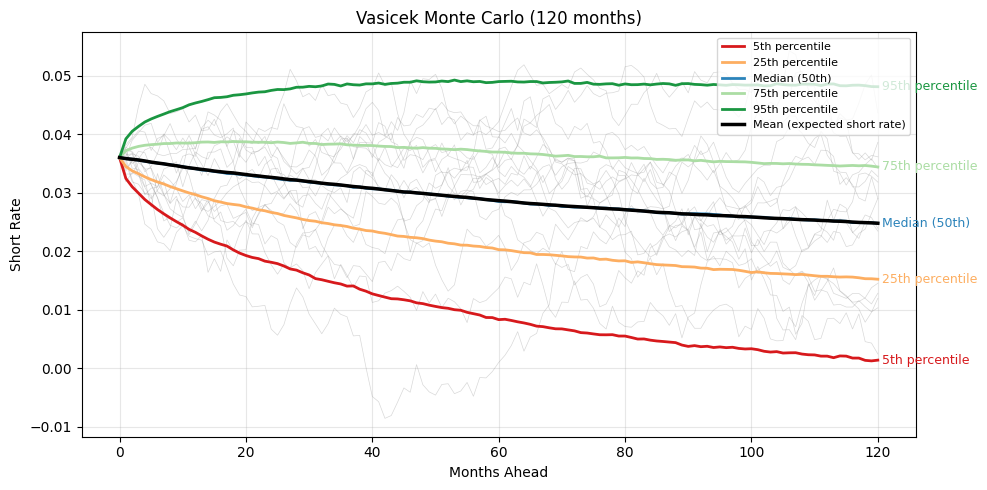


------------------------------------
Mean short rate by month for Vasicek Monte Carlo (120 months)
------------------------------------
Month   0: mean rate = 0.036018
Month   1: mean rate = 0.035839
Month   2: mean rate = 0.035725
Month   3: mean rate = 0.035600
Month   4: mean rate = 0.035432
Month   5: mean rate = 0.035239
Month   6: mean rate = 0.035080
Month   7: mean rate = 0.034943
Month   8: mean rate = 0.034765
Month   9: mean rate = 0.034616
Month  10: mean rate = 0.034422
Month  11: mean rate = 0.034268
Month  12: mean rate = 0.034133
Month  13: mean rate = 0.033990
Month  14: mean rate = 0.033865
Month  15: mean rate = 0.033707
Month  16: mean rate = 0.033581
Month  17: mean rate = 0.033470
Month  18: mean rate = 0.033389
Month  19: mean rate = 0.033251
Month  20: mean rate = 0.033111
Month  21: mean rate = 0.032972
Month  22: mean rate = 0.032865
Month  23: mean rate = 0.032732
Month  24: mean rate = 0.032624
Month  25: mean rate = 0.032511
Month  26: mean rate = 0.032367

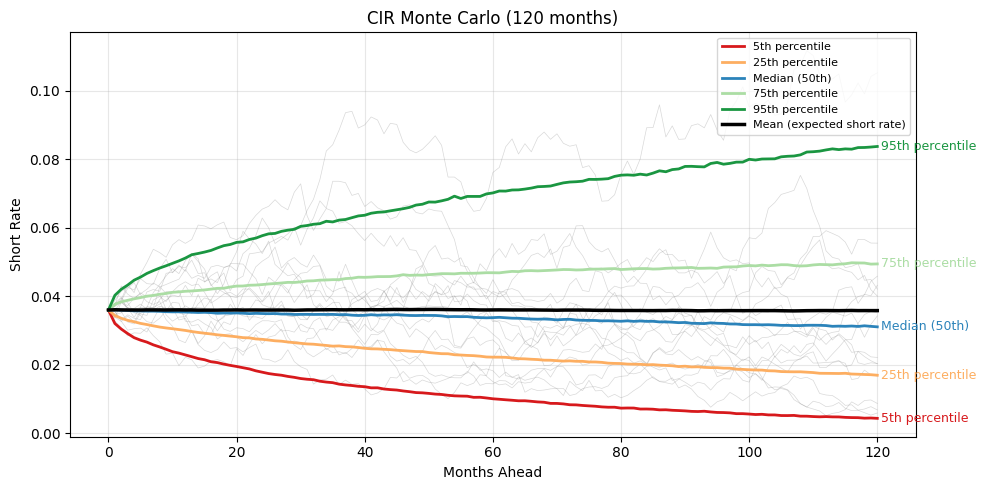


------------------------------------
Mean short rate by month for CIR Monte Carlo (120 months)
------------------------------------
Month   0: mean rate = 0.036018
Month   1: mean rate = 0.036084
Month   2: mean rate = 0.036043
Month   3: mean rate = 0.036020
Month   4: mean rate = 0.036012
Month   5: mean rate = 0.036010
Month   6: mean rate = 0.036044
Month   7: mean rate = 0.036045
Month   8: mean rate = 0.036033
Month   9: mean rate = 0.036017
Month  10: mean rate = 0.036041
Month  11: mean rate = 0.036051
Month  12: mean rate = 0.036021
Month  13: mean rate = 0.036029
Month  14: mean rate = 0.035981
Month  15: mean rate = 0.035987
Month  16: mean rate = 0.035978
Month  17: mean rate = 0.035971
Month  18: mean rate = 0.036006
Month  19: mean rate = 0.036006
Month  20: mean rate = 0.036037
Month  21: mean rate = 0.035994
Month  22: mean rate = 0.036009
Month  23: mean rate = 0.036015
Month  24: mean rate = 0.036000
Month  25: mean rate = 0.036002
Month  26: mean rate = 0.036005
Mon

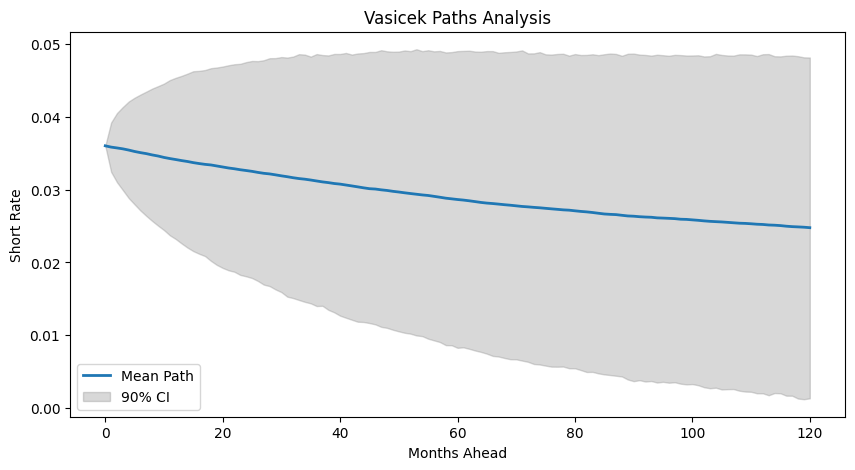

Final mean rate: 0.02477905297812859
Final 5%–95% confidence interval: (np.float64(0.0013541471977435997), np.float64(0.04814020289260002))
Average standard deviation (volatility over time): 0.011226377348396327


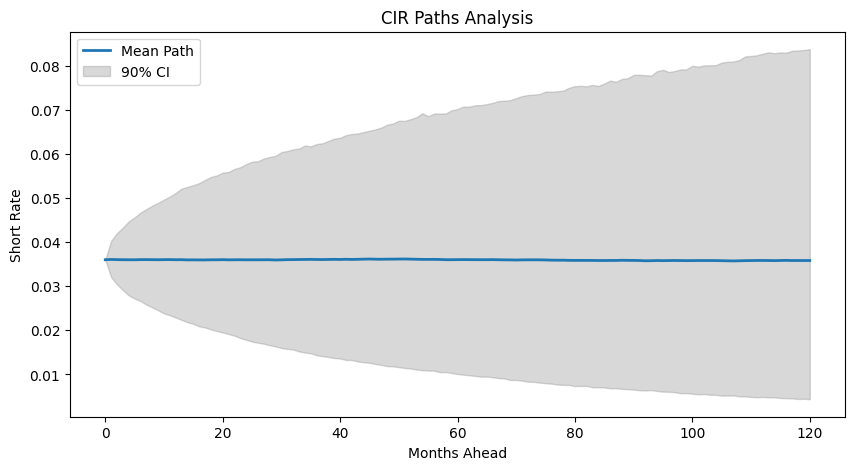

Final mean rate: 0.03584043939756538
Final 5%–95% confidence interval: (np.float64(0.004367662879025368), np.float64(0.08378470632082617))
Average standard deviation (volatility over time): 0.017233722006589822


In [2]:


# 1) Load FRED data (example: 1Y Treasury, monthly, in decimals)
series = fetch_fred_series(
    series_id="DGS1",
    start="1990-01-01",
    end=None,
    as_decimal=True,   # convert % -> decimal if needed
    freq="M"           # resample to monthly average
)

# 2) Choose time step in years (monthly -> 1/12)
dt = 1/12

# 3) Calibrate both models
vas = calibrate_vasicek(series, dt)
cir = calibrate_cir(series.clip(lower=1e-8), dt)  # avoid zeros for CIR

print_model_assumptions()

print("Vasicek:", vas)
print("CIR:", cir)

# 4) Simulate 10 years (120 months) of paths from the last observed rate
r0 = float(series.iloc[-1])
paths_v = simulate_vasicek_paths(vas, r0, n_steps=120, n_paths=10000, dt=dt, seed=42)
paths_c = simulate_cir_paths(cir, r0, n_steps=120, n_paths=10000, dt=dt, seed=42)

# 5) Visualize
plot_fan_chart_with_mean(paths_v, title="Vasicek Monte Carlo (120 months)")
plot_fan_chart_with_mean(paths_c, title="CIR Monte Carlo (120 months)")

analyze_paths(paths_v, title="Vasicek Paths Analysis")
analyze_paths(paths_c, title="CIR Paths Analysis")

c:\Users\lysla\OneDrive\Desktop\MBS Project File\Monte Carlo Rate\stochastic_rates.py:107: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s = s.resample(freq).mean().dropna()


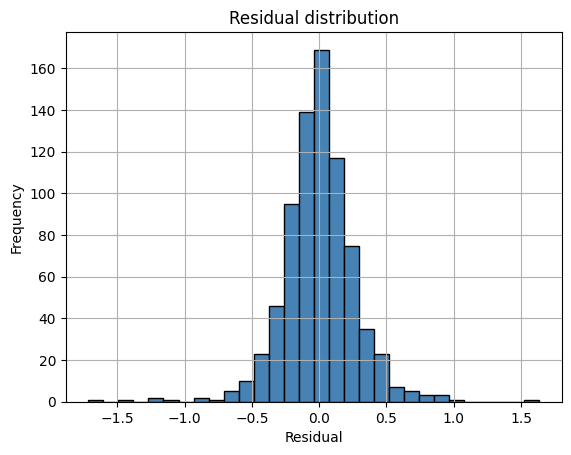

R² of Vasicek OLS fit: 0.9912


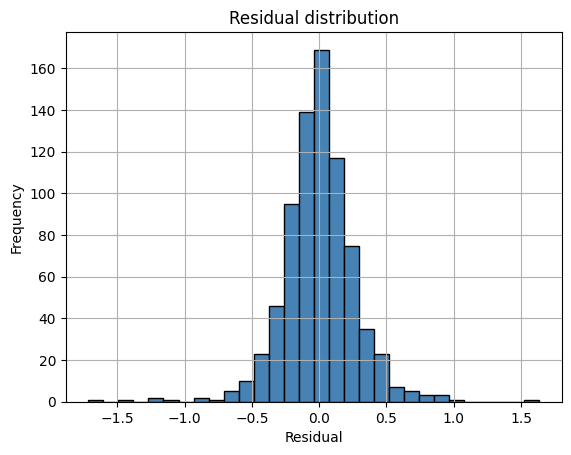

R² of CIR OLS fit: 0.9912

📘 Vasicek Model Assumptions

1. The short rate follows an Ornstein–Uhlenbeck process:
       dr_t = κ(θ – r_t) dt + σ dW_t

2. The process is Gaussian → r_t can become negative.
3. Mean reversion speed κ > 0 pulls rates toward long-run mean θ.
4. Volatility σ is constant over time.
5. The market price of risk is constant (under risk-neutral measure if pricing).
6. Stationary distribution:  N(θ, σ²/(2κ)).
7. Suitable for analytical bond pricing but not for ensuring strictly positive rates.


📗 CIR Model Assumptions

1. The short rate follows a square-root diffusion:
       dr_t = κ(θ – r_t) dt + σ√(r_t) dW_t

2. Volatility depends on √r_t → smaller near zero, preventing negatives.
3. Rates remain non-negative if the Feller condition 2κθ ≥ σ² holds.
4. Mean reversion κ > 0 toward long-run mean θ.
5. Stationary distribution: Gamma(shape = 2κθ/σ², scale = σ²/(2κ)).
6. More realistic for modeling short rates and credit spreads.

Interpretation Tip
Both models desc

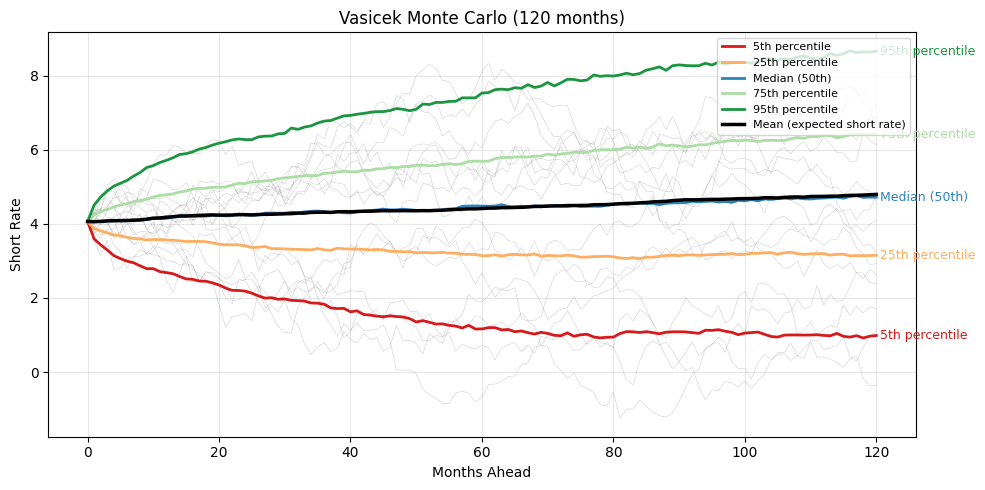


------------------------------------
Mean short rate by month for Vasicek Monte Carlo (120 months)
------------------------------------
Month   0: mean rate = 4.062353
Month   1: mean rate = 4.054871
Month   2: mean rate = 4.067106
Month   3: mean rate = 4.078671
Month   4: mean rate = 4.082434
Month   5: mean rate = 4.086791
Month   6: mean rate = 4.089265
Month   7: mean rate = 4.096115
Month   8: mean rate = 4.103417
Month   9: mean rate = 4.127466
Month  10: mean rate = 4.152804
Month  11: mean rate = 4.159767
Month  12: mean rate = 4.177045
Month  13: mean rate = 4.192407
Month  14: mean rate = 4.209563
Month  15: mean rate = 4.208915
Month  16: mean rate = 4.220229
Month  17: mean rate = 4.228103
Month  18: mean rate = 4.233753
Month  19: mean rate = 4.239714
Month  20: mean rate = 4.234572
Month  21: mean rate = 4.234779
Month  22: mean rate = 4.237835
Month  23: mean rate = 4.246589
Month  24: mean rate = 4.246374
Month  25: mean rate = 4.241358
Month  26: mean rate = 4.249849

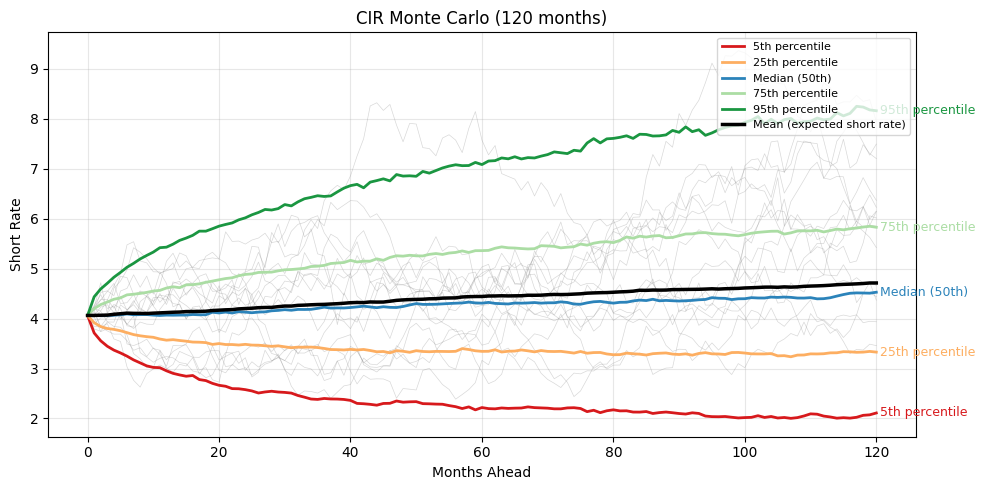


------------------------------------
Mean short rate by month for CIR Monte Carlo (120 months)
------------------------------------
Month   0: mean rate = 4.062353
Month   1: mean rate = 4.063633
Month   2: mean rate = 4.066792
Month   3: mean rate = 4.069349
Month   4: mean rate = 4.085427
Month   5: mean rate = 4.097331
Month   6: mean rate = 4.108777
Month   7: mean rate = 4.104502
Month   8: mean rate = 4.103283
Month   9: mean rate = 4.100902
Month  10: mean rate = 4.108711
Month  11: mean rate = 4.114315
Month  12: mean rate = 4.120363
Month  13: mean rate = 4.126768
Month  14: mean rate = 4.130720
Month  15: mean rate = 4.139842
Month  16: mean rate = 4.141732
Month  17: mean rate = 4.143026
Month  18: mean rate = 4.147409
Month  19: mean rate = 4.161288
Month  20: mean rate = 4.167928
Month  21: mean rate = 4.175263
Month  22: mean rate = 4.179422
Month  23: mean rate = 4.194248
Month  24: mean rate = 4.201108
Month  25: mean rate = 4.207356
Month  26: mean rate = 4.217936
Mon

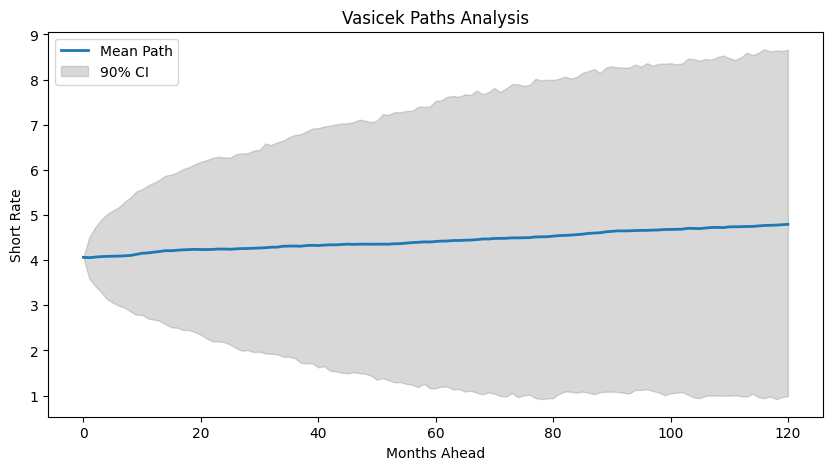

Final mean rate: 4.793812890631998
Final 5%–95% confidence interval: (np.float64(0.9851131597859616), np.float64(8.660635807263779))
Average standard deviation (volatility over time): 1.737411687938105


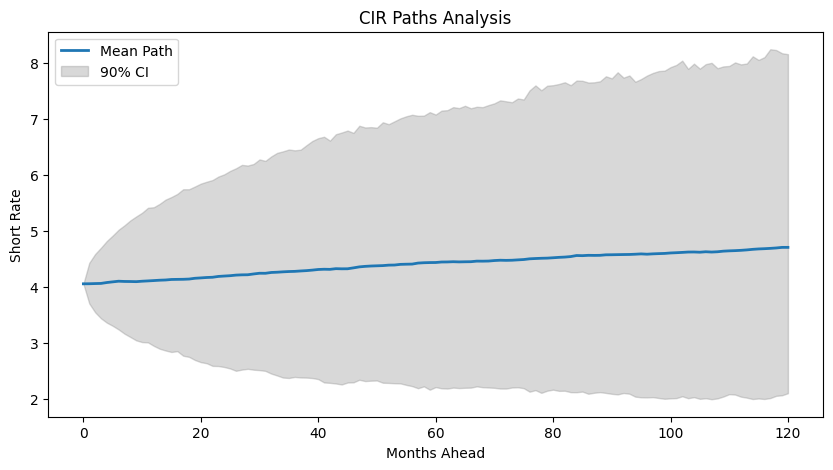

Final mean rate: 4.712988419941618
Final 5%–95% confidence interval: (np.float64(2.109001895294838), np.float64(8.162391496546789))
Average standard deviation (volatility over time): 1.39404433898273
Last observation: 2025-10-31 → 4.0624


In [3]:
from stochastic_rates import load_series_from_csv, calibrate_vasicek, calibrate_cir

series = load_series_from_csv(
    "DGS10 (1).csv",
    date_col="observation_date",
    value_col="DGS10",
    as_decimal=True,
    freq="M"
)
dt = 1/12
vas = calibrate_vasicek(series, dt)
cir = calibrate_cir(series.clip(lower=1e-8), dt)

print_model_assumptions()

print("Vasicek:", vas)
print("CIR:", cir)

# 4) Simulate 10 years (120 months) of paths from the last observed rate
r0 = float(series.iloc[-1])
paths_v = simulate_vasicek_paths(vas, r0, n_steps=120, n_paths=2000, dt=dt, seed=42)
paths_c = simulate_cir_paths(cir, r0, n_steps=120, n_paths=2000, dt=dt, seed=42)

# 5) Visualize
plot_fan_chart_with_mean(paths_v, title="Vasicek Monte Carlo (120 months)")
plot_fan_chart_with_mean(paths_c, title="CIR Monte Carlo (120 months)")

analyze_paths(paths_v, title="Vasicek Paths Analysis")
analyze_paths(paths_c, title="CIR Paths Analysis")

df = pd.read_csv("DGS10 (1).csv")
df["observation_date"] = pd.to_datetime(df["observation_date"])

# Get the last date in that column
last_date = df["observation_date"].iloc[-1]
print("Last observation:", series.index[-1].date(), "→", round(series.iloc[-1], 4))